<a href="https://colab.research.google.com/github/FaizFP/Dicoding--Image/blob/main/Template_Submission_Akhir.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyek Klasifikasi Gambar: [Input Nama Dataset]
- **Nama:** Faiz Firdaus Priyanto
- **Email:** m331d5y0573@student.devacademy.id
- **ID Dicoding:** m331d5y0573

## Import Semua Packages/Library yang Digunakan

In [ ]:
import zipfile
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import shutil
import random
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
import tensorflow as tf
!pip install tensorflowjs


## Data Preparation

In [ ]:
# Path file zip
zip_path = "/content/sample_data/shoessandalboot.zip"

# Folder tujuan ekstraksi
extract_dir = "/content/sample_data/shoessandalboot"

# Ekstrak file zip
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print("✅ Ekstraksi selesai di:", extract_dir)
print("Isi folder:", os.listdir(extract_dir))

✅ Ekstraksi selesai di: /content/sample_data/shoessandalboot
Isi folder: ['Shoe vs Sandal vs Boot Dataset']


### Data Loading

In [ ]:
# Path dataset
data_dir = "/content/sample_data/shoessandalboot/Shoe vs Sandal vs Boot Dataset"

# ImageDataGenerator dengan augmentasi ringan
datagen = ImageDataGenerator(
    rescale=1./255,        # Normalisasi pixel (0–1)
    validation_split=0.2,  # 20% data untuk validasi
)

# Data train
train_data = datagen.flow_from_directory(
    directory=data_dir,
    target_size=(150, 150),   # Sesuaikan dengan input model
    batch_size=32,
    class_mode='categorical', # Karena 3 kelas
    subset='training',
    shuffle=True
)

# Data validasi
val_data = datagen.flow_from_directory(
    directory=data_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

print("Kelas yang terdeteksi:", train_data.class_indices)

Found 12000 images belonging to 3 classes.
Found 3000 images belonging to 3 classes.
Kelas yang terdeteksi: {'Boot': 0, 'Sandal': 1, 'Shoe': 2}


### Data Preprocessing

Found 12000 images belonging to 3 classes.
Found 3000 images belonging to 3 classes.
✅ Preprocessing selesai.
Kelas yang terdeteksi: {'Boot': 0, 'Sandal': 1, 'Shoe': 2}
Bentuk batch gambar: (32, 150, 150, 3)
Bentuk batch label: (32, 3)


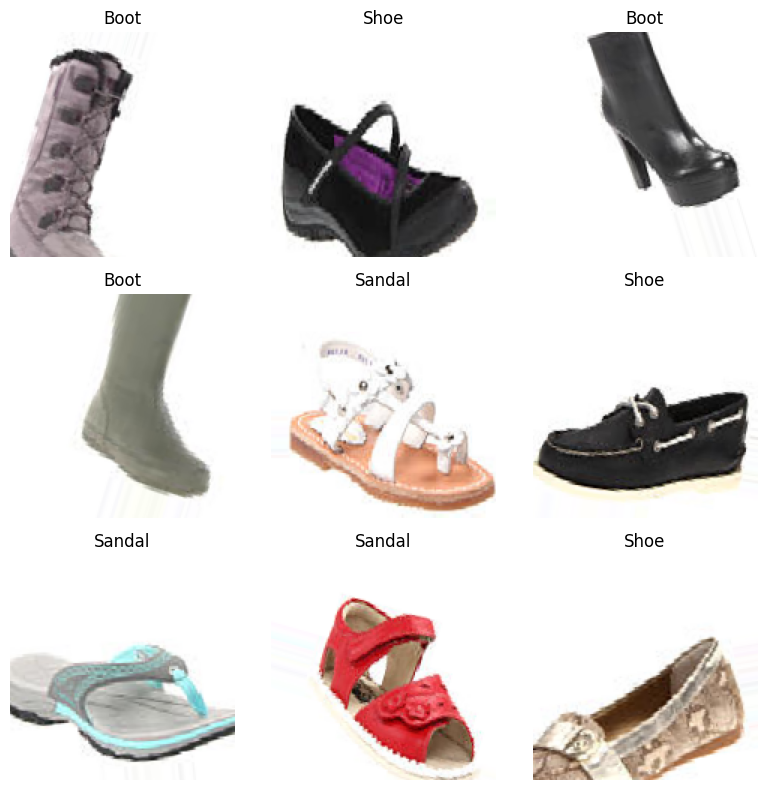

In [ ]:
# Data generator dengan augmentasi untuk training
train_datagen = ImageDataGenerator(
    rescale=1./255,          # Normalisasi 0–1
    rotation_range=20,       # Rotasi acak
    width_shift_range=0.2,   # Geser horizontal
    height_shift_range=0.2,  # Geser vertikal
    shear_range=0.2,         # Shear transform
    zoom_range=0.2,          # Zoom in/out
    horizontal_flip=True,    # Balik horizontal
    validation_split=0.2     # Pisahkan 20% data untuk validasi
)

# Generator untuk data training
train_data = train_datagen.flow_from_directory(
    directory=data_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

# Generator untuk data validasi
val_data = train_datagen.flow_from_directory(
    directory=data_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

print("✅ Preprocessing selesai.")
print("Kelas yang terdeteksi:", train_data.class_indices)

# Cek bentuk data
x_batch, y_batch = next(train_data)
print(f"Bentuk batch gambar: {x_batch.shape}")
print(f"Bentuk batch label: {y_batch.shape}")

# Visualisasi beberapa contoh gambar hasil preprocessing
plt.figure(figsize=(8, 8))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(x_batch[i])
    plt.title(list(train_data.class_indices.keys())[y_batch[i].argmax()])
    plt.axis("off")
plt.tight_layout()
plt.show()

#### Split Dataset

In [ ]:
# Folder baru untuk split
base_split_dir = "/content/sample_data/shoessandalboot_split"
train_dir = os.path.join(base_split_dir, "train")
val_dir   = os.path.join(base_split_dir, "val")
test_dir  = os.path.join(base_split_dir, "test")

# Buat folder split
for folder in [train_dir, val_dir, test_dir]:
    os.makedirs(folder, exist_ok=True)

# Rasio split
train_ratio = 0.7
val_ratio   = 0.15
test_ratio  = 0.15

# Loop setiap kelas
for class_name in os.listdir(data_dir):
    class_path = os.path.join(data_dir, class_name)
    if not os.path.isdir(class_path):
        continue

    # Ambil semua file gambar
    images = os.listdir(class_path)
    random.shuffle(images)

    n_total = len(images)
    n_train = int(n_total * train_ratio)
    n_val   = int(n_total * val_ratio)

    # Split
    train_imgs = images[:n_train]
    val_imgs   = images[n_train:n_train+n_val]
    test_imgs  = images[n_train+n_val:]

    # Buat folder kelas di train/val/test
    for split, split_imgs in zip([train_dir, val_dir, test_dir],
                                 [train_imgs, val_imgs, test_imgs]):
        class_split_dir = os.path.join(split, class_name)
        os.makedirs(class_split_dir, exist_ok=True)
        for img in split_imgs:
            shutil.copy(os.path.join(class_path, img), os.path.join(class_split_dir, img))

print("✅ Dataset berhasil di-split!")
print("Contoh folder train:", os.listdir(train_dir))

✅ Dataset berhasil di-split!
Contoh folder train: ['Sandal', 'Shoe', 'Boot']


**DATA AUGMENTASI UNTUK TRAINING**

In [ ]:
train_dir = "/content/sample_data/shoessandalboot_split/train"
# 1️⃣ Data augmentation untuk training
train_datagen = ImageDataGenerator(
    rescale=1./255,          # normalisasi
    rotation_range=20,       # rotasi acak
    width_shift_range=0.2,   # geser horizontal
    height_shift_range=0.2,  # geser vertikal
    shear_range=0.2,         # shear
    zoom_range=0.2,          # zoom
    horizontal_flip=True
)

# 2️⃣ Data validasi dan testing hanya normalisasi
test_val_datagen = ImageDataGenerator(rescale=1./255)

# Generator training
train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150,150),
    batch_size=32,
    class_mode='categorical',
    shuffle=True
)

# Generator validasi
val_data = test_val_datagen.flow_from_directory(
    val_dir,
    target_size=(150,150),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

# Generator testing
test_data = test_val_datagen.flow_from_directory(
    test_dir,
    target_size=(150,150),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

print("✅ Data loading & preprocessing selesai")
print("Kelas yang terdeteksi:", train_data.class_indices)

Found 10500 images belonging to 3 classes.
Found 2250 images belonging to 3 classes.
Found 2250 images belonging to 3 classes.
✅ Data loading & preprocessing selesai
Kelas yang terdeteksi: {'Boot': 0, 'Sandal': 1, 'Shoe': 2}


## Modelling

In [ ]:
# Ukuran input
IMG_HEIGHT = 150
IMG_WIDTH = 150
CHANNELS = 3
NUM_CLASSES = 3  # boot, sandal, shoe

# 1️⃣ Load pretrained MobileNetV2 sebagai feature extractor
base_model = MobileNetV2(
    input_shape=(IMG_HEIGHT, IMG_WIDTH, CHANNELS),
    include_top=False,  # tanpa fully connected layer
    weights='imagenet'
)
base_model.trainable = False  # freeze weights

# 2️⃣ Bangun model Sequential
model = Sequential([
    base_model,  # pretrained CNN
    Conv2D(32, (3,3), activation='relu', padding='same'),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(64, (3,3), activation='relu', padding='same'),
    MaxPooling2D(pool_size=(2,2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(NUM_CLASSES, activation='softmax')  # output 3 kelas
])

# 3️⃣ Compile model
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 4️⃣ Ringkasan model
model.summary()

/tmp/ipython-input-2528086324.py:8: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 5, 5, 32)       │       368,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 2, 2, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 2, 2, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 1, 1, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,653,859 (10.12 MB)

 Trainable params: 395,875 (1.51 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
"""history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)"""

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
329/329 ━━━━━━━━━━━━━━━━━━━━ 105s 261ms/step - accuracy: 0.6672 - loss: 0.7417 - val_accuracy: 0.9382 - val_loss: 0.1625
Epoch 2/10
110/329 ━━━━━━━━━━━━━━━━━━━━ 39s 180ms/step - accuracy: 0.9036 - loss: 0.2845

KeyboardInterrupt: 

CALLBACKS

In [ ]:
# 1️⃣ Simpan model terbaik
checkpoint_cb = ModelCheckpoint(
    "best_model.h5",
    save_best_only=True,
    monitor="val_loss",
    verbose=1
)

# 2️⃣ Hentikan training jika val_loss tidak membaik
earlystop_cb = EarlyStopping(
    monitor="val_loss",
    patience=5,  # tunggu 5 epoch
    restore_best_weights=True,
    verbose=1
)

# 3️⃣ Turunkan learning rate jika stuck
reduce_lr_cb = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,      # turunkan LR menjadi setengah
    patience=3,      # tunggu 3 epoch
    verbose=1
)

# 4️⃣ Training model dengan callbacks
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=30,
    callbacks=[checkpoint_cb, earlystop_cb, reduce_lr_cb]
)

Epoch 1/30
329/329 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step - accuracy: 0.9153 - loss: 0.2345
Epoch 1: val_loss improved from inf to 0.12482, saving model to best_model.h5


329/329 ━━━━━━━━━━━━━━━━━━━━ 60s 183ms/step - accuracy: 0.9153 - loss: 0.2345 - val_accuracy: 0.9524 - val_loss: 0.1248 - learning_rate: 1.0000e-04
Epoch 2/30
329/329 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step - accuracy: 0.9289 - loss: 0.2008
Epoch 2: val_loss did not improve from 0.12482
329/329 ━━━━━━━━━━━━━━━━━━━━ 59s 181ms/step - accuracy: 0.9289 - loss: 0.2008 - val_accuracy: 0.9373 - val_loss: 0.1652 - learning_rate: 1.0000e-04
Epoch 3/30
329/329 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step - accuracy: 0.9347 - loss: 0.1835
Epoch 3: val_loss improved from 0.12482 to 0.09676, saving model to best_model.h5


329/329 ━━━━━━━━━━━━━━━━━━━━ 60s 181ms/step - accuracy: 0.9347 - loss: 0.1835 - val_accuracy: 0.9649 - val_loss: 0.0968 - learning_rate: 1.0000e-04
Epoch 4/30
329/329 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step - accuracy: 0.9428 - loss: 0.1688
Epoch 4: val_loss did not improve from 0.09676
329/329 ━━━━━━━━━━━━━━━━━━━━ 59s 181ms/step - accuracy: 0.9428 - loss: 0.1688 - val_accuracy: 0.9524 - val_loss: 0.1237 - learning_rate: 1.0000e-04
Epoch 5/30
329/329 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step - accuracy: 0.9442 - loss: 0.1600
Epoch 5: val_loss improved from 0.09676 to 0.08605, saving model to best_model.h5


329/329 ━━━━━━━━━━━━━━━━━━━━ 60s 182ms/step - accuracy: 0.9442 - loss: 0.1600 - val_accuracy: 0.9689 - val_loss: 0.0861 - learning_rate: 1.0000e-04
Epoch 6/30
329/329 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step - accuracy: 0.9479 - loss: 0.1530
Epoch 6: val_loss did not improve from 0.08605
329/329 ━━━━━━━━━━━━━━━━━━━━ 60s 181ms/step - accuracy: 0.9480 - loss: 0.1530 - val_accuracy: 0.9676 - val_loss: 0.0892 - learning_rate: 1.0000e-04
Epoch 7/30
329/329 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step - accuracy: 0.9498 - loss: 0.1364
Epoch 7: val_loss did not improve from 0.08605
329/329 ━━━━━━━━━━━━━━━━━━━━ 61s 185ms/step - accuracy: 0.9498 - loss: 0.1364 - val_accuracy: 0.9569 - val_loss: 0.1090 - learning_rate: 1.0000e-04
Epoch 8/30
329/329 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step - accuracy: 0.9539 - loss: 0.1390
Epoch 8: val_loss improved from 0.08605 to 0.08345, saving model to best_model.h5


329/329 ━━━━━━━━━━━━━━━━━━━━ 61s 185ms/step - accuracy: 0.9539 - loss: 0.1390 - val_accuracy: 0.9702 - val_loss: 0.0835 - learning_rate: 1.0000e-04
Epoch 9/30
329/329 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step - accuracy: 0.9546 - loss: 0.1251
Epoch 9: val_loss did not improve from 0.08345
329/329 ━━━━━━━━━━━━━━━━━━━━ 60s 182ms/step - accuracy: 0.9546 - loss: 0.1251 - val_accuracy: 0.9533 - val_loss: 0.1268 - learning_rate: 1.0000e-04
Epoch 10/30
329/329 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step - accuracy: 0.9559 - loss: 0.1324
Epoch 10: val_loss improved from 0.08345 to 0.07135, saving model to best_model.h5


...

329/329 ━━━━━━━━━━━━━━━━━━━━ 60s 183ms/step - accuracy: 0.9556 - loss: 0.1246 - val_accuracy: 0.9760 - val_loss: 0.0711 - learning_rate: 1.0000e-04
Epoch 12/30
329/329 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step - accuracy: 0.9575 - loss: 0.1196
Epoch 12: val_loss did not improve from 0.07109
329/329 ━━━━━━━━━━━━━━━━━━━━ 61s 185ms/step - accuracy: 0.9575 - loss: 0.1196 - val_accuracy: 0.9680 - val_loss: 0.0830 - learning_rate: 1.0000e-04
Epoch 13/30
329/329 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step - accuracy: 0.9647 - loss: 0.1011
Epoch 13: val_loss improved from 0.07109 to 0.06981, saving model to best_model.h5


329/329 ━━━━━━━━━━━━━━━━━━━━ 60s 183ms/step - accuracy: 0.9647 - loss: 0.1011 - val_accuracy: 0.9742 - val_loss: 0.0698 - learning_rate: 1.0000e-04
Epoch 14/30
329/329 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step - accuracy: 0.9616 - loss: 0.1110
Epoch 14: val_loss improved from 0.06981 to 0.06944, saving model to best_model.h5


329/329 ━━━━━━━━━━━━━━━━━━━━ 61s 186ms/step - accuracy: 0.9616 - loss: 0.1110 - val_accuracy: 0.9747 - val_loss: 0.0694 - learning_rate: 1.0000e-04
Epoch 15/30
329/329 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step - accuracy: 0.9654 - loss: 0.1016
Epoch 15: val_loss did not improve from 0.06944
329/329 ━━━━━━━━━━━━━━━━━━━━ 60s 182ms/step - accuracy: 0.9654 - loss: 0.1016 - val_accuracy: 0.9711 - val_loss: 0.0786 - learning_rate: 1.0000e-04
Epoch 16/30
329/329 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step - accuracy: 0.9650 - loss: 0.1019
Epoch 16: val_loss improved from 0.06944 to 0.06312, saving model to best_model.h5


329/329 ━━━━━━━━━━━━━━━━━━━━ 61s 186ms/step - accuracy: 0.9650 - loss: 0.1019 - val_accuracy: 0.9773 - val_loss: 0.0631 - learning_rate: 1.0000e-04
Epoch 17/30
329/329 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step - accuracy: 0.9670 - loss: 0.0944
Epoch 17: val_loss improved from 0.06312 to 0.05917, saving model to best_model.h5


329/329 ━━━━━━━━━━━━━━━━━━━━ 60s 183ms/step - accuracy: 0.9670 - loss: 0.0944 - val_accuracy: 0.9796 - val_loss: 0.0592 - learning_rate: 1.0000e-04
Epoch 18/30
329/329 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step - accuracy: 0.9665 - loss: 0.1018
Epoch 18: val_loss did not improve from 0.05917
329/329 ━━━━━━━━━━━━━━━━━━━━ 60s 183ms/step - accuracy: 0.9665 - loss: 0.1018 - val_accuracy: 0.9729 - val_loss: 0.0759 - learning_rate: 1.0000e-04
Epoch 19/30
329/329 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step - accuracy: 0.9656 - loss: 0.0904
Epoch 19: val_loss did not improve from 0.05917
329/329 ━━━━━━━━━━━━━━━━━━━━ 61s 186ms/step - accuracy: 0.9656 - loss: 0.0904 - val_accuracy: 0.9800 - val_loss: 0.0603 - learning_rate: 1.0000e-04
Epoch 20/30
328/329 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step - accuracy: 0.9647 - loss: 0.0905
Epoch 20: val_loss did not improve from 0.05917

Epoch 20: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
329/329 ━━━━━━━━━━━━━━━━━━━━ 60s 184ms/step - accuracy: 0.9647 - lo



```

```

## Evaluasi dan Visualisasi

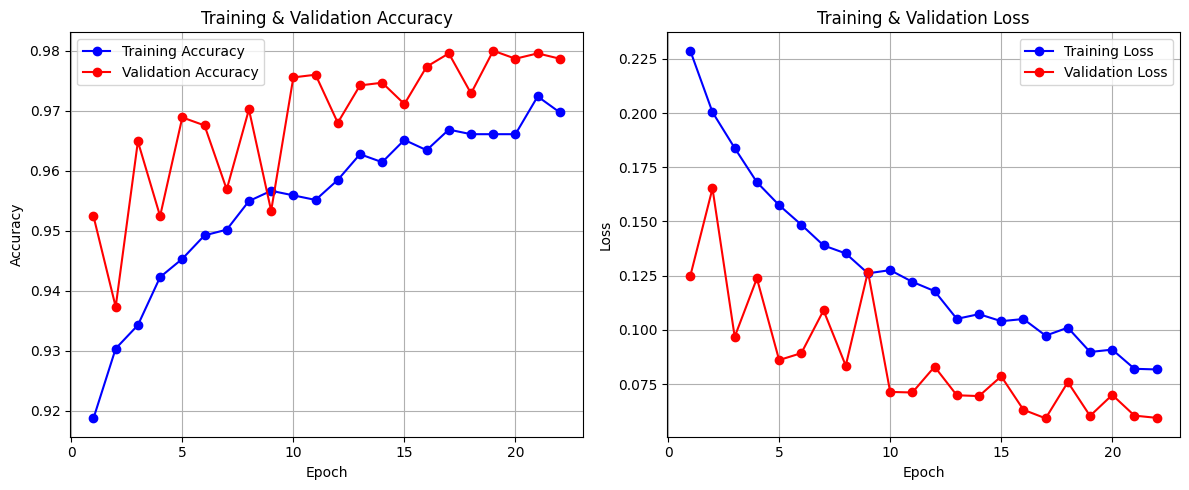

In [ ]:
# --- Ambil history training ---
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc) + 1)

# --- Plot Akurasi ---
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, acc, 'bo-', label='Training Accuracy')
plt.plot(epochs, val_acc, 'ro-', label='Validation Accuracy')
plt.title('Training & Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# --- Plot Loss ---
plt.subplot(1, 2, 2)
plt.plot(epochs, loss, 'bo-', label='Training Loss')
plt.plot(epochs, val_loss, 'ro-', label='Validation Loss')
plt.title('Training & Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Konversi Model

In [ ]:
# --- Folder untuk SavedModel ---
saved_model_path = 'savedModels'
os.makedirs(saved_model_path, exist_ok=True)

# --- Load model Keras ---
model = tf.keras.models.load_model("best_model.h5")

# --- Export ke SavedModel (Keras 3) ---
model.export(saved_model_path)  # buat saved_model.pb + variables/

print(f"✅ Model berhasil diexport ke folder '{saved_model_path}' sebagai SavedModel")

Saved artifact at 'savedModels'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 150, 150, 3), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  132796365433424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132794619689104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132794619689680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132794619690832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132794619689296: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132794619690448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132794619689488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132794113081808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132794619689872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132794619690256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132794113081616: T

## MODEL TF LITE

In [ ]:
# --- Buat folder tflite jika belum ada ---
os.makedirs('tflite', exist_ok=True)

# --- Load model Keras ---
model = tf.keras.models.load_model("best_model.h5")

# --- Konversi ke TensorFlow Lite ---
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

# --- Simpan model .tflite ---
tflite_path = os.path.join('tflite', 'model_sepatu.tflite')
with open(tflite_path, 'wb') as f:
    f.write(tflite_model)

# --- Buat label.txt ---
labels = ['boot', 'sandal', 'shoe']
label_path = os.path.join('tflite', 'label.txt')
with open(label_path, 'w') as f:
    for label in labels:
        f.write(label + '\n')


Saved artifact at '/tmp/tmpf7oql17u'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 150, 150, 3), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  132799204529296: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132796705770384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132796705768080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132796800507664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132796705770768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132796705768848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132796705770192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132796705770000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132796705768272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132796705771728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1327967057711

## TENSOFRLOW JS

In [ ]:
import tensorflowjs as tfjs

# Load model Keras (.h5)
model = tf.keras.models.load_model('best_model.h5')

# Convert dan simpan ke folder TF.js
tfjs.converters.save_keras_model(model, 'model_js')


failed to lookup keras version from the file,
    this is likely a weight only file


### Inference (Optional)

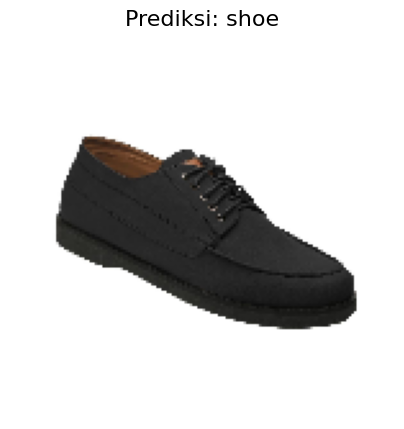

In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np

# --- Path SavedModel ---
saved_model_path = 'savedModels'

# --- Buat TFSMLayer ---
model = tf.keras.Sequential([
    tf.keras.layers.TFSMLayer(saved_model_path, call_endpoint='serving_default')
])

# --- Label ---
labels = ['boot', 'sandal', 'shoe']

# --- Fungsi load & preprocess JPG ---
def load_and_preprocess(img_path, target_size=(150, 150)):
    img = image.load_img(img_path, target_size=target_size)
    img_array = image.img_to_array(img)
    img_array = img_array / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    return img_array, np.array(img)  # convert ke NumPy array untuk plt.imshow

# --- Path gambar ---
img_path = '/content/10.jpg'
img_input, img_orig = load_and_preprocess(img_path)

# --- Prediksi ---
pred_dict = model(img_input)
pred = pred_dict['output_0'].numpy()
pred_label = labels[np.argmax(pred)]

# --- Visualisasi ---
plt.figure(figsize=(5,5))
plt.imshow(img_orig.astype('uint8'))
plt.axis('off')
plt.title(f"Prediksi: {pred_label}", fontsize=16)
plt.show()

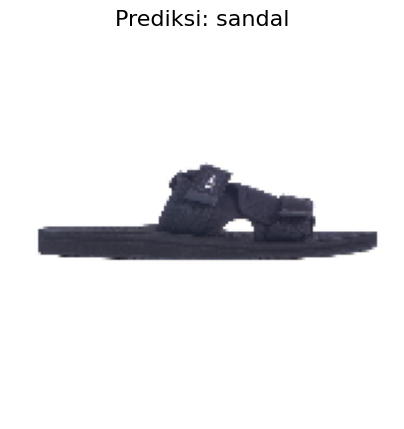

In [ ]:
# --- Path SavedModel ---
saved_model_path = 'savedModels'

# --- Buat TFSMLayer ---
model = tf.keras.Sequential([
    tf.keras.layers.TFSMLayer(saved_model_path, call_endpoint='serving_default')
])

# --- Label ---
labels = ['boot', 'sandal', 'shoe']

# --- Fungsi load & preprocess JPG ---
def load_and_preprocess(img_path, target_size=(150, 150)):
    img = image.load_img(img_path, target_size=target_size)
    img_array = image.img_to_array(img)
    img_array = img_array / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    return img_array, np.array(img)  # convert ke NumPy array untuk plt.imshow

# --- Path gambar ---
img_path = '/content/S01112318HT_2.jpeg'
img_input, img_orig = load_and_preprocess(img_path)

# --- Prediksi ---
pred_dict = model(img_input)
pred = pred_dict['output_0'].numpy()
pred_label = labels[np.argmax(pred)]

# --- Visualisasi ---
plt.figure(figsize=(5,5))
plt.imshow(img_orig.astype('uint8'))
plt.axis('off')
plt.title(f"Prediksi: {pred_label}", fontsize=16)
plt.show()

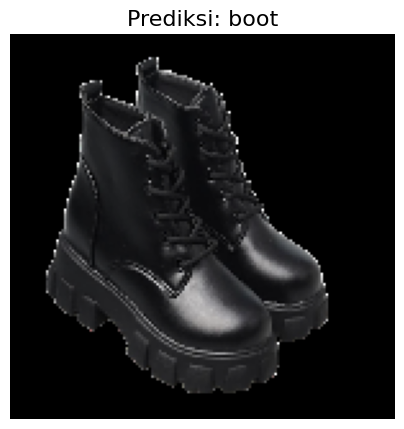

In [ ]:

# --- Path gambar ---
img_path = '/content/a89c6d8e8f03b77f60e3f1a45391f0e7.png'
img_input, img_orig = load_and_preprocess(img_path)

# --- Prediksi ---
pred_dict = model(img_input)
pred = pred_dict['output_0'].numpy()
pred_label = labels[np.argmax(pred)]

# --- Visualisasi ---
plt.figure(figsize=(5,5))
plt.imshow(img_orig.astype('uint8'))
plt.axis('off')
plt.title(f"Prediksi: {pred_label}", fontsize=16)
plt.show()

In [ ]:
pip freeze > requirements.txt
